In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('E:/DATA ANAYLST PROJECTS/Customer-churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1               

In [3]:
print("basic info")
print(df.info())

basic info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
print("null values")
print(df.isnull().sum())

null values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [6]:
# TotalCharges has spaces instead of numbers - fix this
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# Drop the rows with missing TotalCharges
df.dropna(inplace=True)


In [8]:
# Create a numeric version of Churn column
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaned Shape:", df.shape)
print("Churn Rate:", round(df['Churn_Binary'].mean() * 100, 2), "%")

Cleaned Shape: (7032, 22)
Churn Rate: 26.58 %


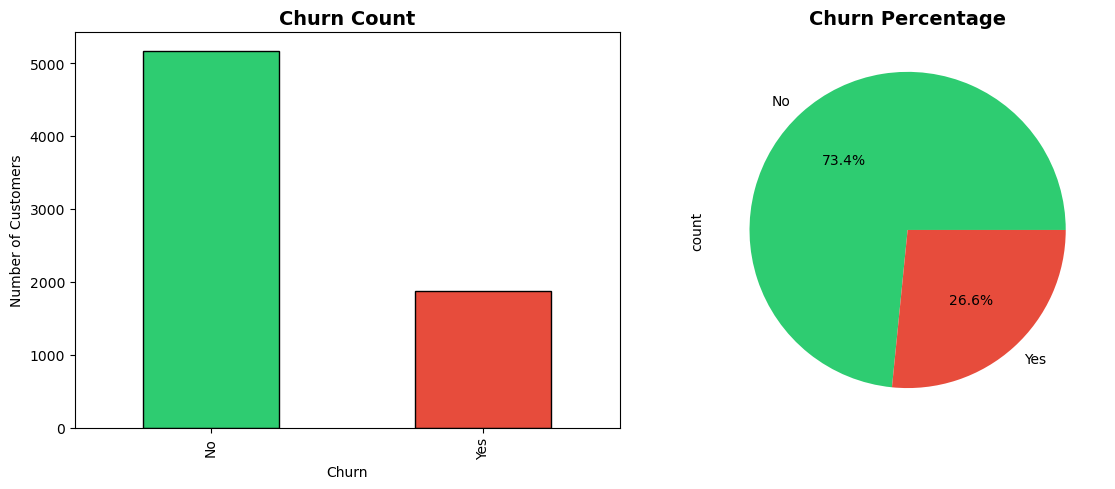

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], 
                                 color=['#2ecc71','#e74c3c'], 
                                 edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Churn')

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], 
                                 autopct='%1.1f%%',
                                 colors=['#2ecc71','#e74c3c'])
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

print("Chart saved!")

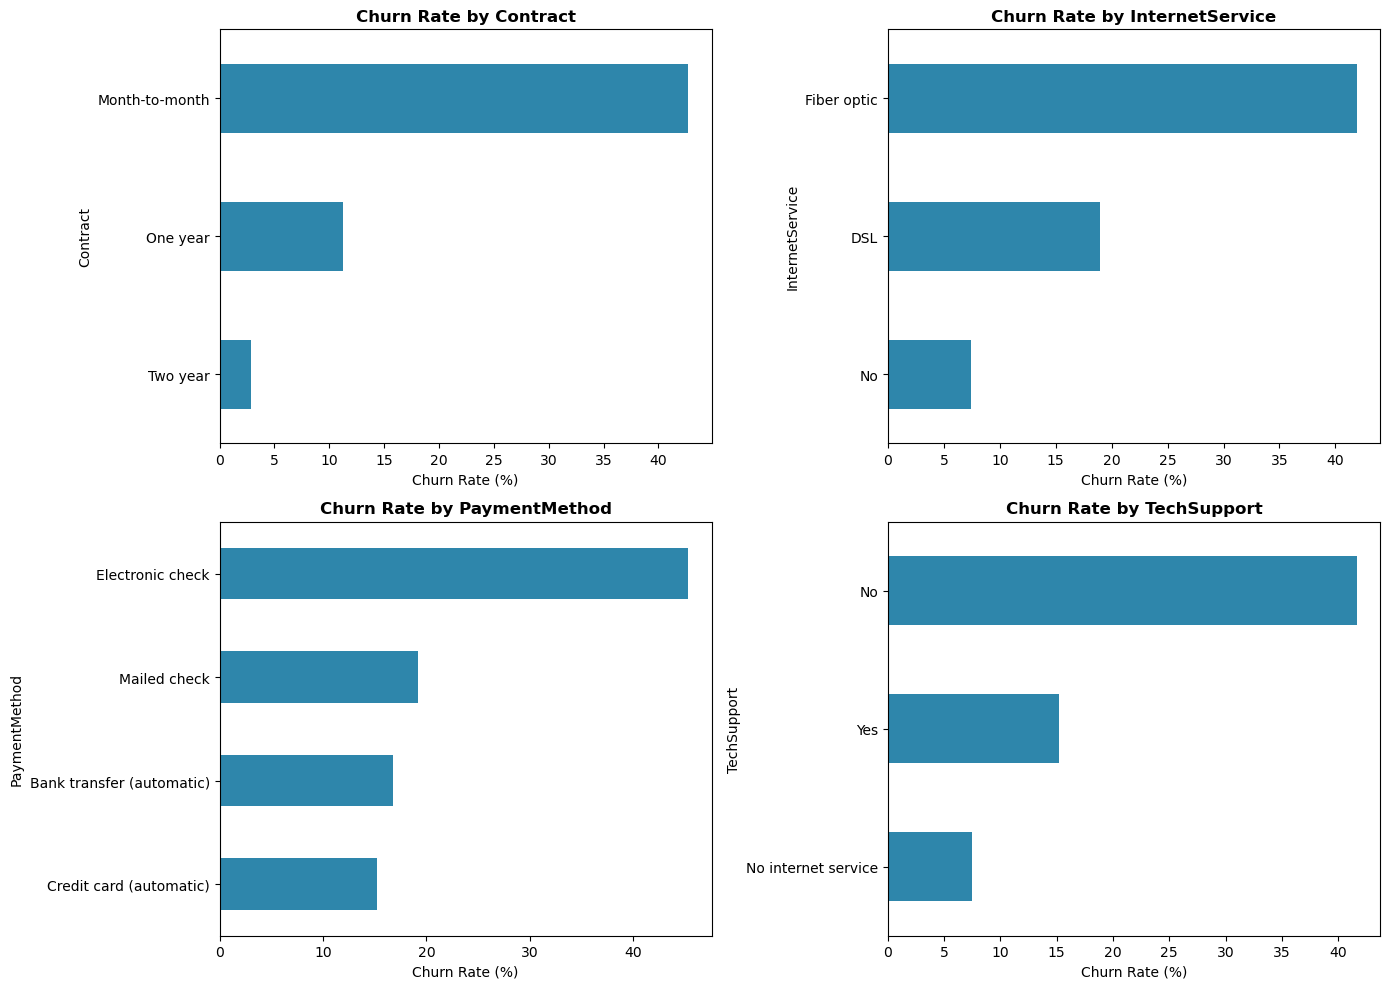

Chart saved!


In [10]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn_Binary'].mean() * 100
    churn_rate.sort_values().plot(kind='barh', ax=axes[i], color='#2E86AB')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150)
plt.show()

print("Chart saved!")

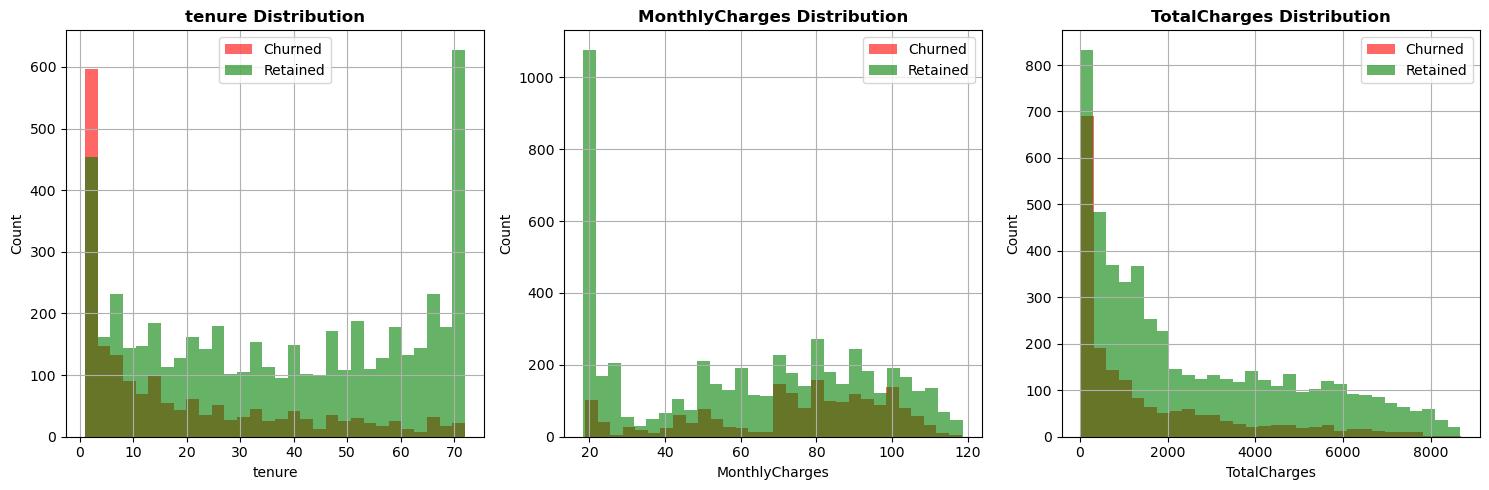

Chart saved!


In [11]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_features):
    df[df['Churn']=='Yes'][col].hist(ax=axes[i], alpha=0.6, 
                                      color='red', label='Churned', bins=30)
    df[df['Churn']=='No'][col].hist(ax=axes[i], alpha=0.6, 
                                     color='green', label='Retained', bins=30)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150)
plt.show()

print("Chart saved!")

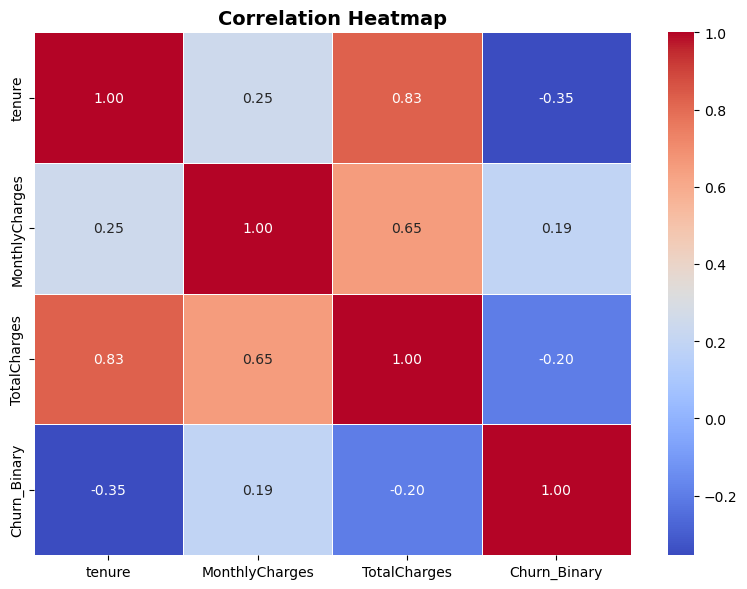

Chart saved!


In [12]:
plt.figure(figsize=(8, 6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Chart saved!")

## Business Observations from EDA

1. Overall churn rate is 26% meaning 1 in 4 customers is leaving

2. Month-to-month contract customers churn the most compared to 
   1 year and 2 year contract customers

3. Customers with Fiber Optic internet have higher churn rate 
   than DSL customers

4. Electronic check payment method has the highest churn rate 
   compared to auto pay customers

5. New customers with low tenure (0-12 months) churn the most — 
   they leave before becoming loyal

6. Customers with high monthly charges and low tenure are the 
   highest risk group

7. Customers without Tech Support churn significantly more than 
   those with Tech Support